# 01 — Price Data
Récupération des prix day-ahead horaires (France) via l'**ENTSO-E Transparency Platform**,
ainsi que des exemples de récupération des fondamentaux (RTE) et de la météo (Open-Meteo).

**Étape du cahier de projet :** Étape 2 — Collecte prix (+ aperçu étapes 3 et 4).

**Prérequis**
- `pip install -r ../requirements.txt`
- Fichier `.env` à la racine du repo avec `ENTSOE_API_KEY`, `RTE_CLIENT_ID`, `RTE_CLIENT_SECRET`
  (voir le README pour comment les obtenir).


In [16]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd

from dotenv import load_dotenv


REPO_ROOT = Path(
    "/Users/evitafaj/Desktop/Portofolio/"
    "electricity-price-forecasting"
)

sys.path.insert(0, str(REPO_ROOT))

ENV_PATH = REPO_ROOT / ".env"
load_dotenv(ENV_PATH, override=True)

if not os.getenv("ENTSOE_API_KEY"):
    raise RuntimeError("La clé ENTSO-E n'a pas été chargée.")

from src.data import fetch_entsoe_day_ahead_prices

print("Setup terminé. Lancement du test ENTSO-E…")

prices_test = fetch_entsoe_day_ahead_prices(
    start="2022-01-01",
    end="2022-01-03",
    country_code="FR",
    api_key=os.environ["ENTSOE_API_KEY"],
)

print("Dimensions :", prices_test.shape)
print(prices_test.head())
print(prices_test.tail())

Setup terminé. Lancement du test ENTSO-E…
Dimensions : (49,)
datetime
2021-12-31 23:00:00+00:00    89.06
2022-01-01 00:00:00+00:00    78.48
2022-01-01 01:00:00+00:00    85.16
2022-01-01 02:00:00+00:00    50.00
2022-01-01 03:00:00+00:00    37.67
Freq: h, Name: price_da, dtype: float64
datetime
2022-01-02 19:00:00+00:00    62.22
2022-01-02 20:00:00+00:00    46.16
2022-01-02 21:00:00+00:00    46.29
2022-01-02 22:00:00+00:00    32.93
2022-01-02 23:00:00+00:00     2.71
Freq: h, Name: price_da, dtype: float64


## 1. Configuration de la période

On commence volontairement sur une période courte (quelques mois) pour valider le pipeline
avant de lancer une collecte sur 2-4 ans (recommandation section 2 du cahier de projet).


In [17]:
START_DATE = "2022-01-01"
END_DATE = "2025-09-30"          # date incluse
END_DATE_EXCLUSIVE = "2025-10-01"
COUNTRY_CODE = "FR"

print(f"Période : {START_DATE} → {END_DATE} inclus")

Période : 2022-01-01 → 2025-09-30 inclus


## 2. Prix day-ahead — ENTSO-E Transparency Platform

Utilise la librairie [`entsoe-py`](https://github.com/EnergieID/entsoe-py), qui encapsule
l'API REST officielle d'ENTSO-E. Clé API gratuite via un compte sur
https://transparency.entsoe.eu (Account Settings → Web API Security Token).


In [18]:
PRICE_PATH = "../data/raw/entsoe_day_ahead_prices_fr.csv"

price_data = pd.read_csv(
    PRICE_PATH,
    parse_dates=["datetime"],
)

prices = (
    price_data
    .set_index("datetime")["price_da"]
    .sort_index()
)

# Sécurisation du fuseau horaire
if prices.index.tz is None:
    prices.index = prices.index.tz_localize("UTC")
else:
    prices.index = prices.index.tz_convert("UTC")

# Filtrage exact de la période
start_utc = pd.Timestamp(
    START_DATE,
    tz="Europe/Paris",
).tz_convert("UTC")

end_utc = pd.Timestamp(
    END_DATE_EXCLUSIVE,
    tz="Europe/Paris",
).tz_convert("UTC")

prices = prices.loc[
    (prices.index >= start_utc)
    & (prices.index < end_utc)
]

prices.name = "price_da"
prices.index.name = "datetime"

print("Nombre d'observations :", len(prices))
prices.head()

Nombre d'observations : 32855


datetime
2021-12-31 23:00:00+00:00    89.06
2022-01-01 00:00:00+00:00    78.48
2022-01-01 01:00:00+00:00    85.16
2022-01-01 02:00:00+00:00    50.00
2022-01-01 03:00:00+00:00    37.67
Name: price_da, dtype: float64

In [10]:
print("Fichier utilisé :", PRICE_PATH)

Fichier utilisé : ../data/raw/entsoe_day_ahead_prices_fr.csv


In [19]:
duplicate_count = prices.index.duplicated().sum()
missing_price_count = prices.isna().sum()

expected_index = pd.date_range(
    start=start_utc,
    end=end_utc,
    freq="h",
    inclusive="left",
)

missing_hours = expected_index.difference(prices.index)
extra_hours = prices.index.difference(expected_index)

print("Doublons :", duplicate_count)
print("Prix manquants :", missing_price_count)
print("Heures manquantes :", len(missing_hours))
print("Heures hors période :", len(extra_hours))

print(
    "Début local :",
    prices.index.min().tz_convert("Europe/Paris"),
)
print(
    "Fin locale :",
    prices.index.max().tz_convert("Europe/Paris"),
)

assert duplicate_count == 0
assert missing_price_count == 0
assert len(missing_hours) == 0
assert len(extra_hours) == 0

print("Tous les contrôles sont validés.")

Doublons : 0
Prix manquants : 0
Heures manquantes : 0
Heures hors période : 0
Début local : 2022-01-01 00:00:00+01:00
Fin locale : 2025-09-30 23:00:00+02:00
Tous les contrôles sont validés.


In [21]:
print("Doublons d'index :", prices.index.duplicated().sum())

expected_index = pd.date_range(prices.index.min(), prices.index.max(), freq="h", tz=prices.index.tz)
missing = expected_index.difference(prices.index)
print(f"Nombre d'heures manquantes : {len(missing)}")
if len(missing) > 0:
    print(missing[:10])

Doublons d'index : 0
Nombre d'heures manquantes : 0


In [20]:
import time
import pandas as pd

periods = [
    ("2022-01-01", "2023-01-01"),
    ("2023-01-01", "2024-01-01"),
    ("2024-01-01", "2025-01-01"),
    ("2025-01-01", "2025-10-01"),
]

parts = []

for start, end in periods:
    print(f"Téléchargement : {start} → {end}")

    part = fetch_entsoe_day_ahead_prices(
        start=start,
        end=end,
        country_code="FR",
        api_key=os.environ["ENTSOE_API_KEY"],
    )

    parts.append(part)
    time.sleep(1)

prices_api = pd.concat(parts).sort_index()

# Retirer les doublons aux frontières entre les requêtes
prices_api = prices_api[
    ~prices_api.index.duplicated(keep="first")
]

# Période exacte : borne de fin exclue
start_utc = pd.Timestamp(
    "2022-01-01",
    tz="Europe/Paris",
).tz_convert("UTC")

end_utc = pd.Timestamp(
    "2025-10-01",
    tz="Europe/Paris",
).tz_convert("UTC")

prices_api = prices_api.loc[
    (prices_api.index >= start_utc)
    & (prices_api.index < end_utc)
]

prices_api.name = "price_da"
prices_api.index.name = "datetime"

print("\nNombre d'observations :", len(prices_api))
print("Début UTC :", prices_api.index.min())
print("Fin UTC :", prices_api.index.max())
print("Doublons :", prices_api.index.duplicated().sum())
print("Prix manquants :", prices_api.isna().sum())

assert len(prices_api) == 32855
assert prices_api.index.duplicated().sum() == 0
assert prices_api.isna().sum() == 0

print("Collecte API complète validée.")

Téléchargement : 2022-01-01 → 2023-01-01
Téléchargement : 2023-01-01 → 2024-01-01
Téléchargement : 2024-01-01 → 2025-01-01
Téléchargement : 2025-01-01 → 2025-10-01

Nombre d'observations : 32852
Début UTC : 2021-12-31 23:00:00+00:00
Fin UTC : 2025-09-30 21:00:00+00:00
Doublons : 0
Prix manquants : 0


AssertionError: 

In [21]:
expected_index = pd.date_range(
    start=start_utc,
    end=end_utc,
    freq="h",
    inclusive="left",
)

missing_api = expected_index.difference(prices_api.index)
extra_api = prices_api.index.difference(expected_index)

print("Heures manquantes dans l'API :", len(missing_api))
print(missing_api)

print("\nHeures supplémentaires :", len(extra_api))
print(extra_api)

Heures manquantes dans l'API : 3
DatetimeIndex(['2022-12-30 23:00:00+00:00', '2023-12-30 23:00:00+00:00',
               '2024-12-30 23:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

Heures supplémentaires : 0
DatetimeIndex([], dtype='datetime64[us, UTC]', freq=None)


In [25]:
from pathlib import Path
import pandas as pd

RAW_DIR = Path(
    "/Users/evitafaj/Desktop/Portofolio/"
    "electricity-price-forecasting/data/raw"
)

# Bornes exactes de la V1
start_utc = pd.Timestamp(
    "2022-01-01",
    tz="Europe/Paris",
).tz_convert("UTC")

end_utc = pd.Timestamp(
    "2025-10-01",
    tz="Europe/Paris",
).tz_convert("UTC")

expected_index = pd.date_range(
    start=start_utc,
    end=end_utc,
    freq="h",
    inclusive="left",
)

# Ajouter les résultats des trois requêtes ciblées
prices_api_fixed = pd.concat(
    [prices_api] + recovery_parts
).sort_index()

prices_api_fixed = prices_api_fixed[
    ~prices_api_fixed.index.duplicated(keep="last")
]

prices_api_fixed = prices_api_fixed.loc[
    (prices_api_fixed.index >= start_utc)
    & (prices_api_fixed.index < end_utc)
]

prices_api_fixed.name = "price_da"
prices_api_fixed.index.name = "datetime"

# Charger le fichier manuel validé
manual_path = RAW_DIR / "entsoe_day_ahead_prices_fr.csv"

prices_manual = pd.read_csv(
    manual_path,
    parse_dates=["datetime"],
    index_col="datetime",
)["price_da"]

prices_manual.index = pd.to_datetime(
    prices_manual.index,
    utc=True,
)

prices_manual = prices_manual.sort_index()

# Contrôles de la collecte API réparée
remaining_missing = expected_index.difference(
    prices_api_fixed.index
)

print("Nombre API final :", len(prices_api_fixed))
print("Heures encore manquantes :", len(remaining_missing))
print("Doublons API :", prices_api_fixed.index.duplicated().sum())
print("Prix API manquants :", prices_api_fixed.isna().sum())

# Comparaison API contre export manuel
comparison = pd.concat(
    [
        prices_manual.rename("manual"),
        prices_api_fixed.rename("api"),
    ],
    axis=1,
)

comparison["absolute_difference"] = (
    comparison["manual"] - comparison["api"]
).abs()

print("\nLignes comparées :", len(comparison))
print("Absentes côté manuel :", comparison["manual"].isna().sum())
print("Absentes côté API :", comparison["api"].isna().sum())
print(
    "Différence maximale :",
    comparison["absolute_difference"].max(),
)
print(
    "Nombre de prix différents :",
    (comparison["absolute_difference"] > 1e-9).sum(),
)

display(
    comparison.sort_values(
        "absolute_difference",
        ascending=False,
    ).head(10)
)

Nombre API final : 32855
Heures encore manquantes : 0
Doublons API : 0
Prix API manquants : 0

Lignes comparées : 32855
Absentes côté manuel : 0
Absentes côté API : 0
Différence maximale : 0.0
Nombre de prix différents : 0


,manual,api,absolute_difference
datetime,,,
2021-12-31 23:00:00+00:00,89.06,89.06,0.0
2024-06-28 02:00:00+00:00,9.63,9.63,0.0
2024-07-02 00:00:00+00:00,34.63,34.63,0.0
2024-07-01 23:00:00+00:00,49.90,49.90,0.0
2024-07-01 22:00:00+00:00,65.53,65.53,0.0
2024-07-01 21:00:00+00:00,87.46,87.46,0.0
2024-07-01 20:00:00+00:00,99.26,99.26,0.0
2024-07-01 19:00:00+00:00,80.79,80.79,0.0
2024-07-01 18:00:00+00:00,71.18,71.18,0.0


In [26]:
recovery_parts = []

for timestamp in missing_api:
    local_day = timestamp.tz_convert("Europe/Paris").normalize()

    query_start = (
        local_day - pd.Timedelta(days=1)
    ).strftime("%Y-%m-%d")

    query_end = (
        local_day + pd.Timedelta(days=2)
    ).strftime("%Y-%m-%d")

    print(
        f"Nouvelle requête autour de {timestamp} : "
        f"{query_start} → {query_end}"
    )

    recovered_part = fetch_entsoe_day_ahead_prices(
        start=query_start,
        end=query_end,
        country_code="FR",
        api_key=os.environ["ENTSOE_API_KEY"],
    )

    recovery_parts.append(recovered_part)

Nouvelle requête autour de 2022-12-30 23:00:00+00:00 : 2022-12-30 → 2023-01-02
Nouvelle requête autour de 2023-12-30 23:00:00+00:00 : 2023-12-30 → 2024-01-02
Nouvelle requête autour de 2024-12-30 23:00:00+00:00 : 2024-12-30 → 2025-01-02


In [27]:
output_path = RAW_DIR / "entsoe_day_ahead_prices_fr.csv"

prices_api_fixed.to_csv(output_path)

print("Fichier API officiel sauvegardé :", output_path)
print("Dimensions :", prices_api_fixed.shape)

Fichier API officiel sauvegardé : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/raw/entsoe_day_ahead_prices_fr.csv
Dimensions : (32855,)


In [28]:
saved_prices = pd.read_csv(
    output_path,
    parse_dates=["datetime"],
    index_col="datetime",
)

saved_prices.index = pd.to_datetime(
    saved_prices.index,
    utc=True,
)

assert saved_prices.shape == (32855, 1)
assert saved_prices.index.duplicated().sum() == 0
assert saved_prices.isna().sum().sum() == 0
assert saved_prices.index.equals(expected_index)

print("Fichier final validé :", saved_prices.shape)

Fichier final validé : (32855, 1)


## 3. (Optionnel) Load & génération par filière — ENTSO-E

Alternative ou complément à RTE : ENTSO-E fournit aussi la demande réalisée et la production
par filière, avec une couverture européenne homogène (utile si tu veux ajouter des pays
voisins pour les spreads, section 6.4).


In [20]:
# Décommenter pour exécuter (peut être lent selon la période demandée)
# load_gen = fetch_entsoe_load_and_generation(START_DATE, END_DATE, COUNTRY_CODE)
# load_gen.head()


## 4. Fondamentaux système français — RTE APIs

Alternative française aux données ENTSO-E, avec potentiellement plus de granularité
(ex. disponibilité nucléaire). Nécessite un compte développeur RTE et la souscription
aux APIs correspondantes sur https://data.rte-france.com.


In [18]:
RTE_START = pd.Timestamp(START_DATE, tz="Europe/Paris").isoformat()
RTE_END = (pd.Timestamp(END_DATE, tz="Europe/Paris") + pd.DateOffset(days=1)).isoformat()

# Décommenter une fois les identifiants RTE configurés dans .env
# consumption = fetch_rte_consumption(RTE_START, RTE_END)
# consumption.head()


In [19]:
# generation = fetch_rte_actual_generation(RTE_START, RTE_END)
# generation_wide = generation.pivot_table(index="datetime", columns="production_type", values="value")
# generation_wide.head()


## 5. Météo historique — Open-Meteo (gratuit, sans clé)

Point météo par défaut : Paris. Pour une meilleure représentativité nationale,
envisager une moyenne pondérée sur plusieurs villes (ex. Paris, Lyon, Marseille, Lille)
selon la répartition de la consommation.


In [22]:
# Étendre la récupération pour couvrir exactement l'index des prix
WEATHER_START = prices.index.min().date().isoformat()
WEATHER_END = prices.index.max().date().isoformat()

weather = fetch_openmeteo_weather(
    start=WEATHER_START,
    end=WEATHER_END,
    latitude=48.85,
    longitude=2.35,
)

# Alignement exact avec les prix
weather = weather.reindex(prices.index)

# Conversion du vent : km/h -> m/s
weather["wind_speed_10m"] = weather["wind_speed_10m"] / 3.6

print("Dimensions :", weather.shape)
print("Valeurs manquantes :")
print(weather.isna().sum())

assert weather.index.equals(prices.index)
assert weather.isna().sum().sum() == 0

weather.head()

NameError: name 'fetch_openmeteo_weather' is not defined

NameError: name 'weather' is not defined

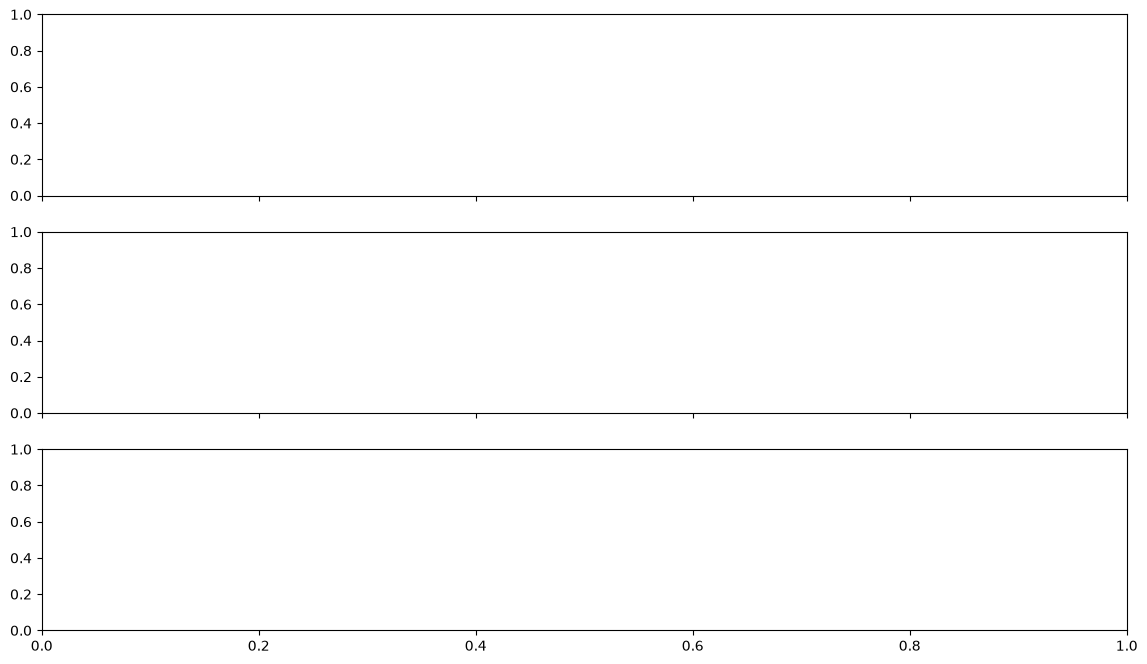

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
weather["temperature_2m"].plot(ax=axes[0], title="Température (°C)")
weather["wind_speed_10m"].plot(ax=axes[1], title="Vent (m/s)")
weather["shortwave_radiation"].plot(ax=axes[2], title="Irradiance (W/m²)")
plt.tight_layout()
plt.show()


In [27]:
weather_path = save_raw(
    weather,
    "openmeteo_weather_paris",
    raw_dir="../data/raw",
    overwrite=True,
)

print("Météo sauvegardée :", weather_path)

Météo sauvegardée : ../data/raw/openmeteo_weather_paris.csv


## 6. Prochaines étapes

- **Notebook 02** : compléter les fondamentaux (nucléaire, hydraulique, échanges,
  gaz/CO2) et étendre la période à 2-4 ans une fois le pipeline validé.
- **Notebook 03** : fusionner toutes les sources sur un index horaire commun,
  gérer les changements d'heure et documenter chaque variable (source, heure
  de publication, transformation).

⚠️ **Rappel anti-leakage** : les séries récupérées ici (`prices`, `weather`) sont des
observations réalisées. Pour un backtest opérationnel réaliste (niveau C, section 8.3),
il faudra remplacer demande/vent/solaire/météo par les **prévisions** qui étaient
disponibles avant la fermeture du marché day-ahead, alignées sur leur heure de publication.
